In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
import time

In [10]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [11]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print(x_train.shape, y_train.shape)

(50000, 32, 32, 3) (50000, 10)


In [12]:
BATCH_SIZE = 32   # ↓ smaller batch avoids OOM

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [13]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [14]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d_1   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                2570      
                                                                 
Total params: 14,848,586
Trainable params: 133,898
Non-trainable params: 14,714,688
____________________________________

In [16]:
start_time = time.time()

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/20
1563/1563 [==============================] - 197s 118ms/step - loss: 2.0721 - accuracy: 0.2620 - val_loss: 1.8101 - val_accuracy: 0.4281
Epoch 2/20
1563/1563 [==============================] - 182s 116ms/step - loss: 1.7385 - accuracy: 0.3925 - val_loss: 1.6179 - val_accuracy: 0.4604
Epoch 3/20
1563/1563 [==============================] - 183s 117ms/step - loss: 1.6080 - accuracy: 0.4373 - val_loss: 1.5181 - val_accuracy: 0.4889
Epoch 4/20
1563/1563 [==============================] - 187s 119ms/step - loss: 1.5288 - accuracy: 0.4652 - val_loss: 1.4511 - val_accuracy: 0.5117
Epoch 5/20
1563/1563 [==============================] - 189s 121ms/step - loss: 1.4698 - accuracy: 0.4868 - val_loss: 1.3970 - val_accuracy: 0.5293
Epoch 6/20
1563/1563 [==============================] - 184s 117ms/step - loss: 1.4238 - accuracy: 0.5021 - val_loss: 1.3527 - val_accuracy: 0.5361
Epoch 7/20
1563/1563 [==============================] - 183s 117ms/step - loss: 1.3814 - accuracy: 0.5182 - val_

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 20.71%
Test Loss: 7.3109


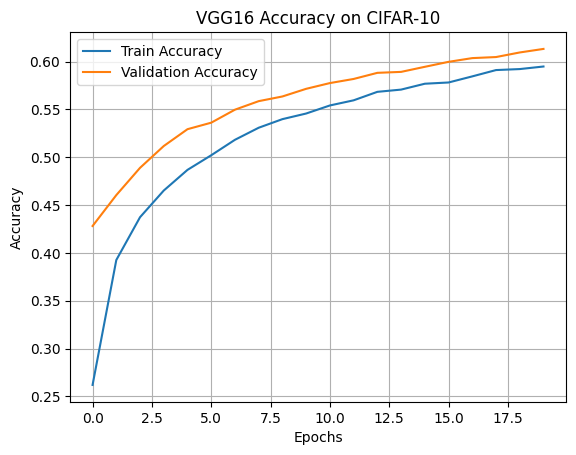

In [18]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('VGG16 Accuracy on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

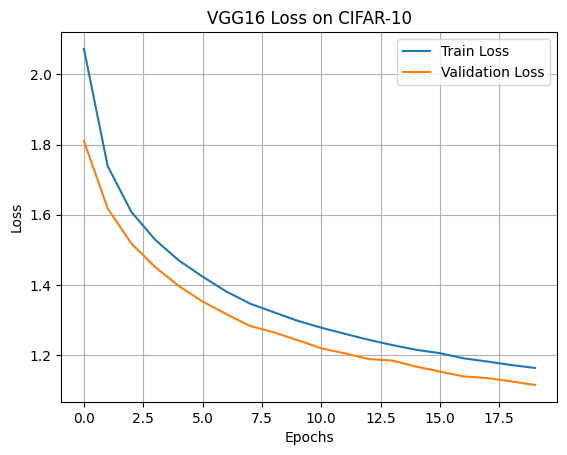

In [19]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VGG16 Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print(f"Total Parameters: {model.count_params():,}")

Total Parameters: 14,848,586
